In [ ]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json

In [164]:
current_directory = Path.cwd().parent
compiled_file_name = Path.joinpath(current_directory, "compiled_output.csv")
output_file_name = Path.joinpath(current_directory, "final_cleaned_compiled.csv")
points_of_interest_file_name = Path.joinpath(current_directory, "points_of_interest.json")

def create_csv_output_file(override=False, csv_data=None):
    if override and Path.exists(output_file_name):
        Path.unlink(output_file_name)
    
    if csv_data is not None:
        csv_data.to_csv(output_file_name, mode='a', header=not Path.exists(output_file_name), index=False)

In [137]:
combined_df = pd.read_csv(compiled_file_name)
print(combined_df.shape)
print(combined_df.head())

(618901, 8)
   Translated Time  Translated Time (minutes)  \
0             1000                   0.016667   
1             1032                   0.017200   
2             1064                   0.017733   
3             1095                   0.018250   
4             1126                   0.018767   

   ADS Reading 1 (Smoothed and Offset)  Calibrated Current 1  \
0                             2.863429              0.008564   
1                            -1.136571             -0.003399   
2                             1.863429              0.005573   
3                             1.863429              0.005573   
4                            -3.136571             -0.009381   

   ADS Reading 2 (Smoothed and Offset)  Calibrated Current 2  \
0                             4.816303              0.014406   
1                             4.816303              0.014406   
2                             4.816303              0.014406   
3                             4.816303              

In [181]:
prev_found_time = -999
# Tuple of time (min) and voltage
last_stable_voltages_before_close = {"index": [], "time": [], "voltage": []}
for index in range(20, len(combined_df)-500):
    CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD = 0.2
    curr = combined_df['Calibrated Voltage'].iloc[index]
    next = combined_df['Calibrated Voltage'].iloc[index+200:index+500].mean()
    
    # Voltage drop + time gap > 1 min + voltage drop > threshold
    if combined_df["Translated Time (minutes)"].iloc[index] - prev_found_time > 1:
        if next < curr and curr - next > CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD:
            print(f"Found potential circuit close at index {index} with voltage drop from {curr:.2f} V to {next:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
            # Take a few step back to get last stable voltage before circuit close
            last_stable_voltages_before_close['index'].append(index)
            last_stable_voltages_before_close['time'].append(combined_df["Translated Time (minutes)"].iloc[index-20:index].mean())
            last_stable_voltages_before_close['voltage'].append(combined_df['Calibrated Voltage'].iloc[index-20:index].mean())
            prev_found_time = combined_df["Translated Time (minutes)"].iloc[index]
    
print("Found", len(last_stable_voltages_before_close['time']), "points")

Found potential circuit close at index 20 with voltage drop from 58.20 V to 56.55 V at time 0.04 min.
Found potential circuit close at index 32058 with voltage drop from 57.05 V to 56.85 V at time 27.50 min.
Found potential circuit close at index 94622 with voltage drop from 56.33 V to 56.13 V at time 74.69 min.
Found potential circuit close at index 157518 with voltage drop from 55.31 V to 55.11 V at time 120.51 min.
Found potential circuit close at index 205837 with voltage drop from 54.10 V to 53.90 V at time 162.84 min.
Found potential circuit close at index 246077 with voltage drop from 53.13 V to 52.92 V at time 194.23 min.
Found potential circuit close at index 279342 with voltage drop from 52.38 V to 52.18 V at time 221.03 min.
Found potential circuit close at index 318421 with voltage drop from 51.80 V to 51.60 V at time 253.12 min.
Found potential circuit close at index 376987 with voltage drop from 51.35 V to 51.15 V at time 297.76 min.
Found potential circuit close at index

In [105]:
print(last_stable_voltages_before_close['time'])
print(last_stable_voltages_before_close['voltage'])
to_drop = []
for index in range(1, len(last_stable_voltages_before_close['time'])):
    if last_stable_voltages_before_close['voltage'][index] > last_stable_voltages_before_close['voltage'][index-1]:
        curr_voltage = last_stable_voltages_before_close['voltage'][index]
        for i in range(index):
            if last_stable_voltages_before_close['voltage'][i] < curr_voltage:
                to_drop.append(i)

print("Dropping indices", to_drop)
last_stable_voltages_before_close['time'] = [time for i, time in enumerate(last_stable_voltages_before_close['time']) if i not in to_drop]
last_stable_voltages_before_close['voltage'] = [voltage for i, voltage in enumerate(last_stable_voltages_before_close['voltage']) if i not in to_drop]
print("After dropping, found", len(last_stable_voltages_before_close['time']), "points")

[np.float64(0.021642500000000002), np.float64(27.4721975), np.float64(74.6692725), np.float64(120.35258000000002), np.float64(121.35286), np.float64(124.04755333333333), np.float64(162.81393333333335), np.float64(167.10720083333334), np.float64(194.21153333333334), np.float64(221.00197500000004), np.float64(253.09399916666666), np.float64(297.73356833333327), np.float64(336.9275966666667), np.float64(381.5558158333334), np.float64(426.1052216666667), np.float64(466.5450158333334), np.float64(475.86219666666665), np.float64(476.8614033333332), np.float64(509.2963925), np.float64(510.2945849999999), np.float64(511.29652999999996), np.float64(512.2992233333333), np.float64(513.2975675)]
[np.float64(58.20104818239796), np.float64(57.049507653061234), np.float64(56.33308469387755), np.float64(55.405996014030634), np.float64(53.076482047193885), np.float64(52.5627493622449), np.float64(54.10178265306123), np.float64(51.80565162627552), np.float64(53.1233093112245), np.float64(52.382390338010

In [182]:
prev_found_time = -999
# Tuple of time (min) and voltage
last_stable_voltages_before_open = {"index": [], "time": [], "voltage": []}
for index in range(20, len(combined_df)-500):
    CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD = 0.5
    curr = combined_df['Calibrated Voltage'].iloc[index]
    next = combined_df['Calibrated Voltage'].iloc[index+200:index+500].mean()
    
    # Voltage drop + time gap > 1 min + voltage drop > threshold
    if combined_df["Translated Time (minutes)"].iloc[index] - prev_found_time > 1:
        if next > curr and next - curr > CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD:
            print(f"Found potential circuit open at index {index} with voltage drop from {curr:.2f} V to {next:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
            # Take a few step back to get last stable voltage before circuit open
            last_stable_voltages_before_open['index'].append(index)
            last_stable_voltages_before_open['time'].append(combined_df["Translated Time (minutes)"].iloc[index-20:index].mean())
            last_stable_voltages_before_open['voltage'].append(combined_df['Calibrated Voltage'].iloc[index-20:index].mean())
            prev_found_time = combined_df["Translated Time (minutes)"].iloc[index]
    
print("Found", len(last_stable_voltages_before_open['time']), "points")

Found potential circuit open at index 12936 with voltage drop from 55.42 V to 55.92 V at time 10.59 min.
Found potential circuit open at index 46343 with voltage drop from 54.60 V to 55.10 V at time 38.51 min.
Found potential circuit open at index 112009 with voltage drop from 53.58 V to 54.09 V at time 87.38 min.
Found potential circuit open at index 168605 with voltage drop from 52.27 V to 52.78 V at time 131.29 min.
Found potential circuit open at index 220339 with voltage drop from 51.49 V to 51.99 V at time 174.22 min.
Found potential circuit open at index 256501 with voltage drop from 50.84 V to 51.34 V at time 204.28 min.
Found potential circuit open at index 294165 with voltage drop from 50.20 V to 50.70 V at time 232.17 min.
Found potential circuit open at index 334928 with voltage drop from 49.62 V to 50.12 V at time 265.89 min.
Found potential circuit open at index 391452 with voltage drop from 49.24 V to 49.74 V at time 308.91 min.
Found potential circuit open at index 4357

In [ ]:
# Drop last 4 points from visual inspection
""" last_stable_voltages_before_close['time'] = last_stable_voltages_before_close['time'][:-4]
last_stable_voltages_before_close['voltage'] = last_stable_voltages_before_close['voltage'][:-4] 
last_stable_voltages_before_close['index'] = last_stable_voltages_before_close['index'][:-4] """

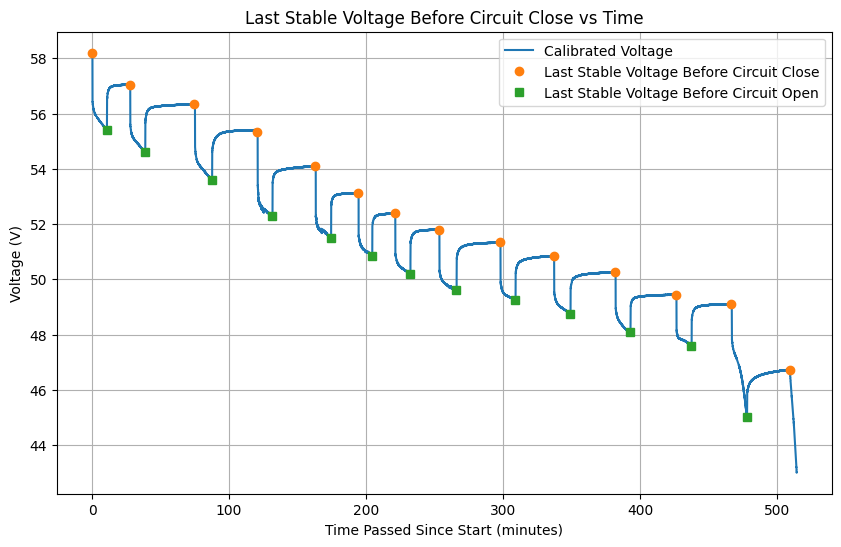

In [179]:
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['Calibrated Voltage'], label='Calibrated Voltage')
plt.plot(last_stable_voltages_before_close['time'], last_stable_voltages_before_close['voltage'], 'o', label='Last Stable Voltage Before Circuit Close')
plt.plot(last_stable_voltages_before_open['time'], last_stable_voltages_before_open['voltage'], 's', label='Last Stable Voltage Before Circuit Open')
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Last Stable Voltage Before Circuit Close vs Time')
plt.legend()
plt.grid()
plt.show()

Found voltage jump at index 612401 from 46.72 V to 48.24 V at time 509.51 min.
Voltage dropped back down at index 613381 from 46.71 V to 46.71 V at time 510.50 min.
Index before jump: 612400, Index after jump: 613381


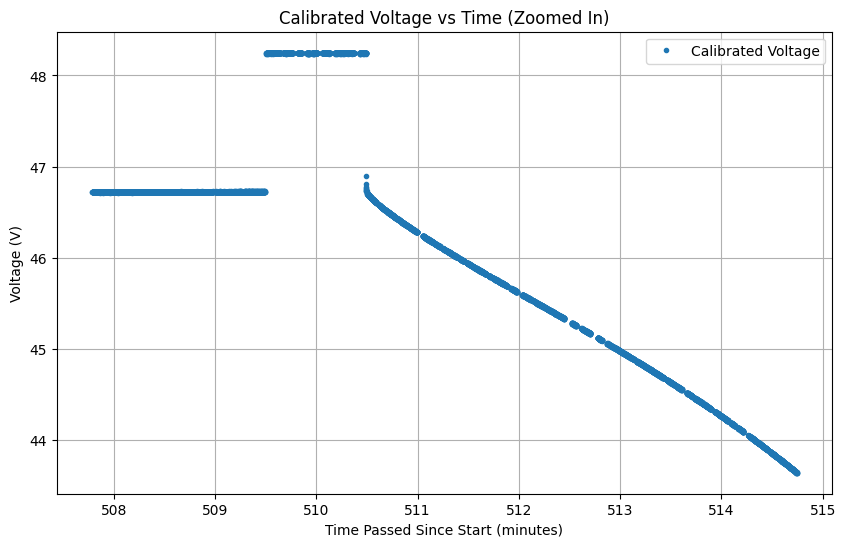

In [139]:
# Visual inspection of anormally

before_jump = -1
index_before_jump = -1
index_after_jump = -1

for index in range(610000, len(combined_df)-1):
    curr = combined_df['Calibrated Voltage'].iloc[index]
    prev = combined_df['Calibrated Voltage'].iloc[index-1]
    if before_jump == -1 and curr - prev > 1:
        before_jump = prev
        index_before_jump = index - 1
        print(f"Found voltage jump at index {index} from {before_jump:.2f} V to {curr:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
    if curr < before_jump:
        index_after_jump = index
        print(f"Voltage dropped back down at index {index} from {curr:.2f} V to {combined_df['Calibrated Voltage'].iloc[index]:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
        break
print(f"Index before jump: {index_before_jump}, Index after jump: {index_after_jump}")

plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'][610000:618000], combined_df['Calibrated Voltage'][610000:618000], '.', label='Calibrated Voltage', )
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Calibrated Voltage vs Time (Zoomed In)')
plt.legend()
plt.grid()

In [140]:
if index_before_jump != -1 and index_after_jump != -1:
    # Shift the timings after jump to before and remove the range of the jump
    time_shift = combined_df['Translated Time'].iloc[index_after_jump] - combined_df['Translated Time'].iloc[index_before_jump]
    print(f"Shifting timings after index {index_after_jump} by {time_shift:.2f} seconds.")
    combined_df['Translated Time'] = combined_df['Translated Time'].apply(lambda x: x - time_shift if x > combined_df['Translated Time'].iloc[index_after_jump] else x)
    print(f"Removing indices from {index_before_jump+1} to {index_after_jump}.")
    combined_df = combined_df.drop(index=range(index_before_jump+1, index_after_jump+1))
    
    combined_df['Translated Time (minutes)'] = combined_df['Translated Time'] / 60000
    print(f"Shifted timings after index {index_after_jump} by {time_shift:.2f} seconds and removed indices from {index_before_jump+1} to {index_after_jump}.")
    index_before_jump = -1
    index_after_jump = -1
else:
    print("Did not find a valid voltage jump to correct.")

Shifting timings after index 613381 by 60766.00 seconds.
Removing indices from 612401 to 613381.
Shifted timings after index 613381 by 60766.00 seconds and removed indices from 612401 to 613381.


In [ ]:
create_csv_output_file(override=True, csv_data=combined_df)

In [184]:
outpus_json_points = {
    "before_close": {
        "index": last_stable_voltages_before_close['index'],
        "time": last_stable_voltages_before_close['time'],
        "voltage": last_stable_voltages_before_close['voltage']
    },
    "before_open": {
        "index": last_stable_voltages_before_open['index'],
        "time": last_stable_voltages_before_open['time'],
        "voltage": last_stable_voltages_before_open['voltage']
    }
}
print(f"Saved {len(last_stable_voltages_before_close['index'])} points for before close and {len(last_stable_voltages_before_open['time'])} points for before open to {points_of_interest_file_name}.")
json.dump(outpus_json_points, open(points_of_interest_file_name, 'w'), indent=4)

Saved 14 points for before close and 13 points for before open to c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\points_of_interest.json.
